In [ ]:

!apt-get -qq update
!apt-get -qq -y install fonts-nanum fontconfig
!fc-cache -fv


!rm -rf ~/.cache/matplotlib

import os
from matplotlib import font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
assert os.path.exists(font_path), "NanumGothic.ttf 파일이 없습니다."

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용된 폰트:", font_name)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no

# **증가율 데이터 만들기**

In [ ]:

!apt-get -qq update
!apt-get -qq -y install fonts-nanum fontconfig
!fc-cache -fv


!rm -rf ~/.cache/matplotlib

# --- (3) 파이썬에서 폰트 파일을 Matplotlib에 직접 등록(addfont) ---
import os
from matplotlib import font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
assert os.path.exists(font_path), "NanumGothic.ttf 파일이 없습니다."

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# --- (4) 이제 pyplot 임포트 + 기본 폰트로 지정 ---
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용된 폰트:", font_name)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

In [ ]:
import pandas as pd

ev_path = "202001_202601_전기차등록현황.csv"
ch_path = "202512년_지역별_전기차_충전기_구축현황(누적) (1).csv"

# 1) 헤더 없이 읽기
ev_raw = pd.read_csv(ev_path, encoding="utf-8-sig", header=None)
ch_raw = pd.read_csv(ch_path, encoding="utf-8-sig", header=None)




In [ ]:
#  EV 헤더 교체
ev = ev_raw.copy()
ev.columns = ev.iloc[3]
ev = ev.iloc[4:].reset_index(drop=True)

# 컬럼명 문자열화 + 중복 제거
ev.columns = ev.columns.astype(str)
ev = ev.loc[:, ~ev.columns.duplicated()]

# 숫자형 변환
for c in ev.columns:
    if c != "년월":
        ev[c] = pd.to_numeric(ev[c], errors="coerce")




전기차 등록현황에서 년월 있는 행 자동으로 찾아 작용하는 전처리

In [ ]:
import pandas as pd

ev_path = "202001_202601_전기차등록현황.csv"
ev_raw = pd.read_csv(ev_path, encoding="utf-8-sig", header=None)

In [ ]:
import pandas as pd

ev_path = "202001_202601_전기차등록현황.csv"
ev_raw = pd.read_csv(ev_path, encoding="utf-8-sig", header=None)

# 1) '년월'이 들어있는 헤더 행 찾기
header_idx = None
for i in range(0, 50):  # 앞 50줄에서 찾기
    row_as_text = ev_raw.iloc[i].astype(str).tolist()
    if "년월" in row_as_text:
        header_idx = i
        break

In [ ]:
# 2) 헤더 적용 + 데이터 부분만 남기기
ev = ev_raw.copy()
ev.columns = ev.iloc[header_idx]
ev = ev.iloc[header_idx + 1:].reset_index(drop=True)

# 컬럼명 문자열로 정리
ev.columns = ev.columns.astype(str)

# 중복 컬럼 제거
ev = ev.loc[:, ~ev.columns.duplicated()]

In [ ]:
for c in ev.columns:
    if c != "년월":
        ev[c] = pd.to_numeric(ev[c], errors="coerce")

In [ ]:
import pandas as pd

ev_path = "202001_202601_전기차등록현황.csv"
ch_path = "202512년_지역별_전기차_충전기_구축현황(누적) (1).csv"

def read_with_header_row(path, keyword="년월", enc="utf-8-sig", max_scan=30):
    raw = pd.read_csv(path, header=None, encoding=enc)

    header_idx = None
    for i in range(min(max_scan, len(raw))):
        row = raw.iloc[i].astype(str).tolist()
        if keyword in row:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"헤더 줄을 못 찾았어요. '{keyword}'가 있는 줄이 없음")

    df = raw.copy()
    df.columns = df.iloc[header_idx]
    df = df.iloc[header_idx + 1:].reset_index(drop=True)

    # 컬럼명 정리
    df.columns = df.columns.astype(str)
    df = df.loc[:, ~df.columns.duplicated()]

    return df, header_idx

ev, ev_header_idx = read_with_header_row(ev_path, keyword="년월")
ch, ch_header_idx = read_with_header_row(ch_path, keyword="년월")


out_path = "/content/충전기_설치현황.csv"
ch.to_csv(out_path, index=False, encoding="utf-8-sig")

print("저장 완료:", out_path)




저장 완료: /content/충전기_설치현황.csv


In [ ]:
# EV 숫자 변환
for c in ev.columns:
    if c != "년월":
        ev[c] = pd.to_numeric(ev[c], errors="coerce")

# wide -> long
ev_long = ev.melt(id_vars=["년월"], var_name="시도", value_name="전기차대수")
ev_long["전기차대수"] = pd.to_numeric(ev_long["전기차대수"], errors="coerce")
ev_long = ev_long.dropna(subset=["전기차대수"])

# '합계' 제거
ev_long = ev_long[ev_long["시도"] != "합계"]

def sido_to_region(s):
    if s in ["서울", "인천", "경기", "강원", "제주"]:
        return s
    if s in ["충북", "충남", "대전", "세종"]:
        return "충청"
    if s in ["전북", "전남", "광주"]:
        return "전라"
    if s in ["경북", "경남", "대구", "부산", "울산"]:
        return "경상"
    return "기타"

ev_long["권역"] = ev_long["시도"].apply(sido_to_region)
ev_group = ev_long.groupby(["년월", "권역"], as_index=False)["전기차대수"].sum()




In [ ]:
# CH 숫자 변환
for c in ch.columns:
    if c not in ["년월", "충전속도"]:
        ch[c] = pd.to_numeric(ch[c], errors="coerce")

# wide -> long
ch_long = ch.melt(id_vars=["년월", "충전속도"], var_name="권역", value_name="충전기수")
ch_long["충전기수"] = pd.to_numeric(ch_long["충전기수"], errors="coerce")
ch_long = ch_long.dropna(subset=["충전기수"])

# 권역별(년월별)로 완속+급속 합계
ch_group = ch_long.groupby(["년월", "권역"], as_index=False)["충전기수"].sum()

out_path = "/content/충전기_설치_최종현황.csv"
ch.to_csv(out_path, index=False, encoding="utf-8-sig")

print("저장 완료:", out_path)


저장 완료: /content/충전기_설치_최종현황.csv


In [ ]:
# 날짜형으로 바꿔서 기간 필터
ev_group["년월_dt"] = pd.to_datetime(ev_group["년월"] + "-01")
ch_group["년월_dt"] = pd.to_datetime(ch_group["년월"] + "-01")

start = pd.to_datetime("2020-01-01")
end   = pd.to_datetime("2026-01-01")

ev_group = ev_group[(ev_group["년월_dt"] >= start) & (ev_group["년월_dt"] <= end)]
ch_group = ch_group[(ch_group["년월_dt"] >= start) & (ch_group["년월_dt"] <= end)]

df = pd.merge(
    ev_group.drop(columns=["년월_dt"]),
    ch_group.drop(columns=["년월_dt"]),
    on=["년월", "권역"],
    how="inner"
)


out_path = "/content/충전기_전기차.csv"
df.to_csv(out_path, index=False, encoding="utf-8-sig")

print("저장 완료:", out_path)


저장 완료: /content/충전기_전기차.csv


In [ ]:
# 전체 상관계수(피어슨)
corr_all = df["전기차대수"].corr(df["충전기수"])
print("\n[전체 상관계수] 전기차대수 vs 충전기수 =", corr_all)

# 권역별 상관계수
corr_by_region = df.groupby("권역").apply(lambda x: x["전기차대수"].corr(x["충전기수"]))
print("\n[권역별 상관계수]")
print(corr_by_region.sort_values(ascending=False))



[전체 상관계수] 전기차대수 vs 충전기수 = 0.9544041060944641

[권역별 상관계수]
권역
경상    0.991271
경기    0.990622
전라    0.987172
인천    0.984336
충청    0.982792
서울    0.981163
강원    0.967137
제주    0.934210
dtype: float64


/tmp/ipython-input-3676042937.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_by_region = df.groupby("권역").apply(lambda x: x["전기차대수"].corr(x["충전기수"]))


In [ ]:
import pandas as pd

# df: (년월, 권역, 전기차대수, 충전기수) 가 있다고 가정
df = df.copy()

df["EV1000대당충전기"] = (df["충전기수"] / df["전기차대수"]) * 1000

print(df.head())




        년월  권역  전기차대수    충전기수  EV1000대당충전기
0  2020-12  강원   3540  1634.0   461.581921
1  2020-12  경기  16116  7597.0   471.394887
2  2020-12  경상  26463  7684.0   290.367683
3  2020-12  서울  17463  4031.0   230.830900
4  2020-12  인천   4581  1147.0   250.382013


In [ ]:
import pandas as pd

df["년월_dt"] = pd.to_datetime(df["년월"] + "-01")
df["연도"] = df["년월_dt"].dt.year

print(df[["년월", "연도"]].head())


        년월    연도
0  2020-12  2020
1  2020-12  2020
2  2020-12  2020
3  2020-12  2020
4  2020-12  2020


In [ ]:
yearly_ratio = (
    df.groupby("연도", as_index=False)["EV1000대당충전기"]
      .mean()
)

print(yearly_ratio)


     연도  EV1000대당충전기
0  2020   357.027201
1  2021   500.074354
2  2022   489.906036
3  2023   536.026724
4  2024   654.666783
5  2025   653.638263


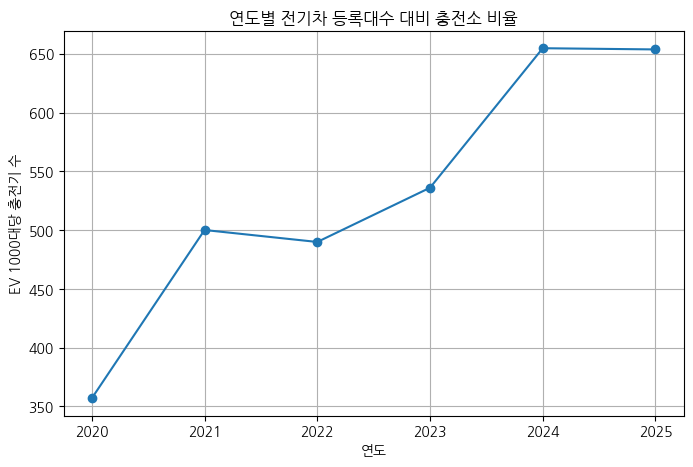

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(
    yearly_ratio["연도"],
    yearly_ratio["EV1000대당충전기"],
    marker="o"
)

plt.title("연도별 전기차 등록대수 대비 충전소 비율")
plt.xlabel("연도")
plt.ylabel("EV 1000대당 충전기 수")
plt.grid(True)
plt.show()


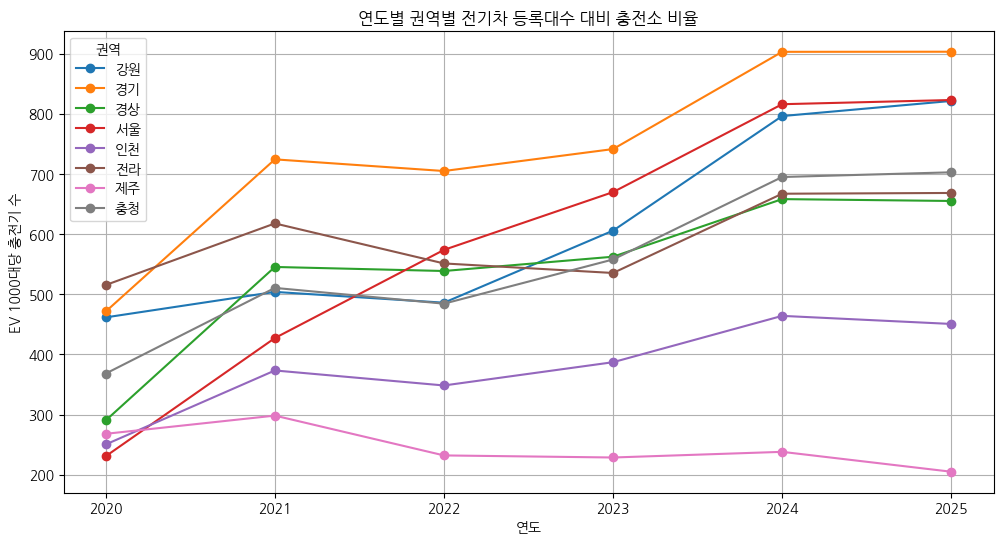

저장 완료: /content/전기차_등록대수대비_충전소비율.csv


In [ ]:
year_region = (
    df.groupby(["연도", "권역"], as_index=False)["EV1000대당충전기"]
      .mean()
)

pivot = year_region.pivot(
    index="연도",
    columns="권역",
    values="EV1000대당충전기"
)

plt.figure(figsize=(12,6))

for region in pivot.columns:
    plt.plot(pivot.index, pivot[region], marker="o", label=region)

plt.title("연도별 권역별 전기차 등록대수 대비 충전소 비율")
plt.xlabel("연도")
plt.ylabel("EV 1000대당 충전기 수")
plt.grid(True)
plt.legend(title="권역")
plt.show()

out_path = "/content/전기차_등록대수대비_충전소비율.csv"
year_region.to_csv(out_path, index=False, encoding="utf-8-sig")

print("저장 완료:", out_path)


# 유가 변화량에 따른 전기차 판매량 증가 **비율**

In [ ]:
# 라이브러리 불러오기

import pandas as pd
import matplotlib.pyplot as plt

# 파일 경로 변수로 저장
ev_path  = "202001_202601_전기차등록현황.csv"
oil_path = "주유소_평균판매가격.csv"


In [ ]:
# 라이브러리 불러오기
import pandas as pd

# 전기차 등록현황 CSV 읽기
ev_path = "202001_202601_전기차등록현황.csv"
ev_raw = pd.read_csv(ev_path, encoding="utf-8-sig", header=None)



          0      1      2      3      4      5      6      7     8       9   \
0  전기차 등록 현황    NaN    NaN    NaN    NaN    NaN    NaN    NaN   NaN     NaN   
1        NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   NaN     NaN   
2        NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   NaN     NaN   
3         년월     서울     부산     대구     인천     광주     대전     울산    세종      경기   
4    2025-10  87135  50122  34515  71284  16277  22387  12485  6718  166319   
5    2025-09  85696  48615  33855  69854  16055  21942  12201  6572  161456   

      10     11     12     13     14     15     16     17      18  
0    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN  
1    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN  
2    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN  
3     강원     충북     충남     전북     전남     경북     경남     제주      합계  
4  20398  25862  28961  22764  33094  29951  52778  47302  728352  
5  19940  25428  28511  22232  32412  

In [ ]:
# 한글이 깨져서 표준 컬럼명 직접 부여
std_cols = ["년월","서울","부산","대구","인천","광주","대전","울산","세종",
            "경기","강원","충북","충남","전북","전남","경북","경남","제주","합계"]


# 컬럼 개수가 19개일 때만 표준 컬럼명으로 갈아끼움
if len(ev.columns) == 19:
    ev.columns = std_cols #std_cols 에 적어둔 이름은 왼쪽부터 순서대로 붙임


# 확인용
print("EV 컬럼명:", list(ev.columns))
print(ev.head())


EV 컬럼명: ['년월', '서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기', '강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주', '합계']
        년월     서울     부산     대구     인천     광주     대전     울산    세종      경기  \
0  2025-10  87135  50122  34515  71284  16277  22387  12485  6718  166319   
1  2025-09  85696  48615  33855  69854  16055  21942  12201  6572  161456   
2  2025-08  83422  46482  33064  66866  15568  21397  11762  6349  154913   
3  2025-07  81359  44383  31969  64676  15300  20901  11413  6085  149813   
4  2025-06  80069  42604  31004  62840  14831  20261  11026  5804  144064   

      강원     충북     충남     전북     전남     경북     경남     제주      합계  
0  20398  25862  28961  22764  33094  29951  52778  47302  728352  
1  19940  25428  28511  22232  32412  29474  51085  46094  711422  
2  19320  24653  27764  21682  31582  28225  47461  44819  685329  
3  18896  24301  26483  21330  30554  27286  46109  43825  664683  
4  18310  23595  25845  20475  29451  25910  43767  42843  642699  


In [ ]:
# 년월은 건드리지 않고, 나머지 컬럼만 숫자로 변경

for c in ev.columns:
    if c != "년월":
        ev[c] = pd.to_numeric(ev[c], errors="coerce") # 숫자로 바꿀 수 없는 값은 Nan

print(ev.head())


        년월     서울     부산     대구     인천     광주     대전     울산    세종      경기  \
0  2025-10  87135  50122  34515  71284  16277  22387  12485  6718  166319   
1  2025-09  85696  48615  33855  69854  16055  21942  12201  6572  161456   
2  2025-08  83422  46482  33064  66866  15568  21397  11762  6349  154913   
3  2025-07  81359  44383  31969  64676  15300  20901  11413  6085  149813   
4  2025-06  80069  42604  31004  62840  14831  20261  11026  5804  144064   

      강원     충북     충남     전북     전남     경북     경남     제주      합계  
0  20398  25862  28961  22764  33094  29951  52778  47302  728352  
1  19940  25428  28511  22232  32412  29474  51085  46094  711422  
2  19320  24653  27764  21682  31582  28225  47461  44819  685329  
3  18896  24301  26483  21330  30554  27286  46109  43825  664683  
4  18310  23595  25845  20475  29451  25910  43767  42843  642699  


In [ ]:
print(ev.columns)
print(ev[["년월","서울","경기","제주","합계"]].head(3))


Index(['년월', '서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기', '강원', '충북',
       '충남', '전북', '전남', '경북', '경남', '제주', '합계'],
      dtype='object')
        년월     서울      경기     제주      합계
0  2025-10  87135  166319  47302  728352
1  2025-09  85696  161456  46094  711422
2  2025-08  83422  154913  44819  685329


In [ ]:
# wide -> long
ev_long = ev.melt(id_vars=["년월"], var_name="시도", value_name="전기차대수")

# 합계 제거
ev_long = ev_long[ev_long["시도"] != "합계"].reset_index(drop=True)

print(ev_long.head())
print("시도 종류 개수:", ev_long["시도"].nunique())


        년월  시도  전기차대수
0  2025-10  서울  87135
1  2025-09  서울  85696
2  2025-08  서울  83422
3  2025-07  서울  81359
4  2025-06  서울  80069
시도 종류 개수: 17


In [ ]:
def sido_to_region(s):
    if s in ["서울", "인천", "경기", "강원", "제주"]:
        return s
    if s in ["충북", "충남", "대전", "세종"]:
        return "충청"
    if s in ["전북", "전남", "광주"]:
        return "전라"
    if s in ["경북", "경남", "대구", "부산", "울산"]:
        return "경상"
    return "기타"

ev_long["권역"] = ev_long["시도"].apply(sido_to_region)

# 권역별 월별 전기차대수 합계(= 누적)
ev_region = ev_long.groupby(["년월", "권역"], as_index=False)["전기차대수"].sum()

print(ev_region.head())
print("권역 종류:", ev_region["권역"].unique())


        년월  권역  전기차대수
0  2020-01  강원   2036
1  2020-01  경기   9159
2  2020-01  경상  20056
3  2020-01  서울   9989
4  2020-01  인천   2202
권역 종류: ['강원' '경기' '경상' '서울' '인천' '전라' '제주' '충청']


In [ ]:
ev_region["년월_dt"] = pd.to_datetime(ev_region["년월"] + "-01")
ev_region = ev_region.sort_values(["권역", "년월_dt"]).reset_index(drop=True)

ev_region["EV증가율(%)"] = ev_region.groupby("권역")["전기차대수"].pct_change() * 100

print(ev_region.head(12))


         년월  권역  전기차대수      년월_dt   EV증가율(%)
0   2020-01  강원   2036 2020-01-01        NaN
1   2020-02  강원   2046 2020-02-01   0.491159
2   2020-03  강원   2313 2020-03-01  13.049853
3   2020-04  강원   2476 2020-04-01   7.047125
4   2020-05  강원   2587 2020-05-01   4.483037
5   2020-06  강원   2774 2020-06-01   7.228450
6   2020-07  강원   2976 2020-07-01   7.281903
7   2020-08  강원   3128 2020-08-01   5.107527
8   2020-09  강원   3333 2020-09-01   6.553708
9   2020-10  강원   3359 2020-10-01   0.780078
10  2020-11  강원   3422 2020-11-01   1.875558
11  2020-12  강원   3540 2020-12-01   3.448276


In [ ]:
import pandas as pd

oil_path = "주유소_평균판매가격.csv"
oil0 = pd.read_csv(oil_path, encoding="cp949", encoding_errors="replace")

print("유가 컬럼명 전체:")
print(list(oil0.columns))

print("\n유가 데이터 상위 5행:")
print(oil0.head())


유가 컬럼명 전체:
['구분', '보통휘발유', '자동차용경유']

유가 데이터 상위 5행:
         구분    보통휘발유   자동차용경유
0  2020년1분기  1527.21  1349.22
1  2020년2분기  1300.03  1108.24
2  2020년3분기  1358.00  1160.37
3  2020년4분기  1340.43  1140.85
4  2021년1분기  1473.07  1273.06


In [ ]:
date_candidates = ["년월", "날짜", "기준일", "일자", "date", "Date"]
date_col = None
for cand in date_candidates:
    if cand in oil0.columns:
        date_col = cand
        break

print("선택된 날짜 컬럼:", date_col)


선택된 날짜 컬럼: None


In [ ]:
price_candidates = [
    "휘발유", "보통휘발유", "가솔린", "Gasoline",
    "평균판매가격", "평균가격", "판매가격", "가격", "단가",
    "전국평균", "전국 평균", "평균", "원/L"
]

price_col = None
for cand in price_candidates:
    if cand in oil0.columns:
        price_col = cand
        break

print("선택된 가격 컬럼:", price_col)


선택된 가격 컬럼: 보통휘발유


In [ ]:
date_col = "구분"
price_col = "보통휘발유"

print(oil0[[date_col, price_col]].head(10))
print("구분 컬럼 예시(유니크 10개):", oil0[date_col].astype(str).unique()[:10])


         구분    보통휘발유
0  2020년1분기  1527.21
1  2020년2분기  1300.03
2  2020년3분기  1358.00
3  2020년4분기  1340.43
4  2021년1분기  1473.07
5  2021년2분기  1551.00
6  2021년3분기  1639.19
7  2021년4분기  1698.27
8  2022년1분기  1764.07
9  2022년2분기  2008.72
구분 컬럼 예시(유니크 10개): ['2020년1분기' '2020년2분기' '2020년3분기' '2020년4분기' '2021년1분기' '2021년2분기'
 '2021년3분기' '2021년4분기' '2022년1분기' '2022년2분기']


In [ ]:
oil = oil0.copy()

oil["연도"] = oil["구분"].str.extract(r"(\d{4})").astype(int)
oil["분기"] = oil["구분"].str.extract(r"(\d)분기").astype(int)

print(oil[["구분", "연도", "분기"]].head())


         구분    연도  분기
0  2020년1분기  2020   1
1  2020년2분기  2020   2
2  2020년3분기  2020   3
3  2020년4분기  2020   4
4  2021년1분기  2021   1


In [ ]:
quarter_to_month = {1: 1, 2: 4, 3: 7, 4: 10}

oil["시작월"] = oil["분기"].map(quarter_to_month)

oil["년월_dt"] = pd.to_datetime(
    oil["연도"].astype(str) + "-" +
    oil["시작월"].astype(str).str.zfill(2) + "-01"
)

print(oil[["구분", "년월_dt"]].head())


         구분      년월_dt
0  2020년1분기 2020-01-01
1  2020년2분기 2020-04-01
2  2020년3분기 2020-07-01
3  2020년4분기 2020-10-01
4  2021년1분기 2021-01-01


In [ ]:
price_col = "보통휘발유"
oil[price_col] = pd.to_numeric(oil[price_col], errors="coerce")


In [ ]:
expanded_rows = []

for _, row in oil.iterrows():
    for m in range(3):  # 분기당 3개월
        expanded_rows.append({
            "년월_dt": row["년월_dt"] + pd.DateOffset(months=m),
            "보통휘발유": row["보통휘발유"]
        })

oil_month = pd.DataFrame(expanded_rows)
oil_month = oil_month.sort_values("년월_dt").reset_index(drop=True)

print(oil_month.head(12))


        년월_dt    보통휘발유
0  2020-01-01  1527.21
1  2020-02-01  1527.21
2  2020-03-01  1527.21
3  2020-04-01  1300.03
4  2020-05-01  1300.03
5  2020-06-01  1300.03
6  2020-07-01  1358.00
7  2020-08-01  1358.00
8  2020-09-01  1358.00
9  2020-10-01  1340.43
10 2020-11-01  1340.43
11 2020-12-01  1340.43


In [ ]:
oil_month["유가증가율(%)"] = oil_month["보통휘발유"].pct_change() * 100

print(oil_month.head(12))


        년월_dt    보통휘발유   유가증가율(%)
0  2020-01-01  1527.21        NaN
1  2020-02-01  1527.21   0.000000
2  2020-03-01  1527.21   0.000000
3  2020-04-01  1300.03 -14.875492
4  2020-05-01  1300.03   0.000000
5  2020-06-01  1300.03   0.000000
6  2020-07-01  1358.00   4.459128
7  2020-08-01  1358.00   0.000000
8  2020-09-01  1358.00   0.000000
9  2020-10-01  1340.43  -1.293814
10 2020-11-01  1340.43   0.000000
11 2020-12-01  1340.43   0.000000


In [ ]:
merged = pd.merge(
    ev_region,
    oil_month,
    on="년월_dt",
    how="inner"
)

merged = merged.dropna(subset=["EV증가율(%)", "유가증가율(%)"]).reset_index(drop=True)

print(merged[["년월_dt", "권역", "EV증가율(%)", "유가증가율(%)"]].head())
print("병합 행 수:", len(merged))


       년월_dt  권역   EV증가율(%)   유가증가율(%)
0 2020-02-01  강원   0.491159   0.000000
1 2020-03-01  강원  13.049853   0.000000
2 2020-04-01  강원   7.047125 -14.875492
3 2020-05-01  강원   4.483037   0.000000
4 2020-06-01  강원   7.228450   0.000000
병합 행 수: 552


In [ ]:
corr = merged["EV증가율(%)"].corr(merged["유가증가율(%)"])
print("EV 증가율 vs 유가 증가율 상관계수:", corr)


EV 증가율 vs 유가 증가율 상관계수: 0.0206376918905144


In [ ]:
import pandas as pd

ev_path = "202001_202601_전기차등록현황.csv"

ev_raw = pd.read_csv(
    ev_path,
    encoding="cp949",
    encoding_errors="replace",  # 깨지는 문자를 '�'로 바꿔서 읽음
    header=None
)

print(ev_raw.head(10))


                 0      1      2      3      4      5      6      7     8   \
0  癤우쟾湲곗감 �벑濡� �쁽�솴    NaN    NaN    NaN    NaN    NaN    NaN    NaN   NaN   
1               NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   NaN   
2               NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   NaN   
3              �뀈�썡   �꽌�슱   遺��궛  ���援�   �씤泥�    愿묒＜  ����쟾   �슱�궛  �꽭醫�   
4           2025-10  87135  50122  34515  71284  16277  22387  12485  6718   
5           2025-09  85696  48615  33855  69854  16055  21942  12201  6572   
6           2025-08  83422  46482  33064  66866  15568  21397  11762  6349   
7           2025-07  81359  44383  31969  64676  15300  20901  11413  6085   
8           2025-06  80069  42604  31004  62840  14831  20261  11026  5804   
9           2025-05  78227  42159  30556  56465  14309  20404  10750  5708   

       9      10     11     12     13     14     15     16     17      18  
0     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN

In [ ]:
header = ev_raw.iloc[3]      # 4번째 줄(인덱스 3)이 헤더
ev = ev_raw.iloc[4:].copy()  # 5번째 줄부터 데이터

ev.columns = header
ev = ev.reset_index(drop=True)

print(ev.head())
print("컬럼 개수:", len(ev.columns))


3       년월     서울     부산     대구     인천     광주     대전     울산    세종      경기  \
0  2025-10  87135  50122  34515  71284  16277  22387  12485  6718  166319   
1  2025-09  85696  48615  33855  69854  16055  21942  12201  6572  161456   
2  2025-08  83422  46482  33064  66866  15568  21397  11762  6349  154913   
3  2025-07  81359  44383  31969  64676  15300  20901  11413  6085  149813   
4  2025-06  80069  42604  31004  62840  14831  20261  11026  5804  144064   

3     강원     충북     충남     전북     전남     경북     경남     제주      합계  
0  20398  25862  28961  22764  33094  29951  52778  47302  728352  
1  19940  25428  28511  22232  32412  29474  51085  46094  711422  
2  19320  24653  27764  21682  31582  28225  47461  44819  685329  
3  18896  24301  26483  21330  30554  27286  46109  43825  664683  
4  18310  23595  25845  20475  29451  25910  43767  42843  642699  
컬럼 개수: 19


In [ ]:
# 표준 컬럼명 생성하기

std_cols = ["년월","서울","부산","대구","인천","광주","대전","울산","세종",
            "경기","강원","충북","충남","전북","전남","경북","경남","제주","합계"]

# 컬럼 개수가 맞을 때만 교체
if len(ev.columns) == 19:
    ev.columns = std_cols

print(ev.columns)
print(ev[["년월","서울","경기","제주","합계"]].head(3))


Index(['년월', '서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기', '강원', '충북',
       '충남', '전북', '전남', '경북', '경남', '제주', '합계'],
      dtype='object')
        년월     서울      경기     제주      합계
0  2025-10  87135  166319  47302  728352
1  2025-09  85696  161456  46094  711422
2  2025-08  83422  154913  44819  685329


In [ ]:
for c in ev.columns:
    if c != "년월":
        ev[c] = pd.to_numeric(ev[c], errors="coerce")

print(ev.dtypes.head(10))
print(ev.head(3))


년월    object
서울     int64
부산     int64
대구     int64
인천     int64
광주     int64
대전     int64
울산     int64
세종     int64
경기     int64
dtype: object
        년월     서울     부산     대구     인천     광주     대전     울산    세종      경기  \
0  2025-10  87135  50122  34515  71284  16277  22387  12485  6718  166319   
1  2025-09  85696  48615  33855  69854  16055  21942  12201  6572  161456   
2  2025-08  83422  46482  33064  66866  15568  21397  11762  6349  154913   

      강원     충북     충남     전북     전남     경북     경남     제주      합계  
0  20398  25862  28961  22764  33094  29951  52778  47302  728352  
1  19940  25428  28511  22232  32412  29474  51085  46094  711422  
2  19320  24653  27764  21682  31582  28225  47461  44819  685329  


In [ ]:
print(ev[["년월","서울","경기","제주","합계"]].head(3))


        년월     서울      경기     제주      합계
0  2025-10  87135  166319  47302  728352
1  2025-09  85696  161456  46094  711422
2  2025-08  83422  154913  44819  685329


In [ ]:
import pandas as pd

ev["년월_dt"] = pd.to_datetime(ev["년월"] + "-01")
ev = ev.sort_values("년월_dt").reset_index(drop=True)

print(ev[["년월", "년월_dt"]].head(3))
print(ev[["년월", "년월_dt"]].tail(3))


        년월      년월_dt
0  2020-01 2020-01-01
1  2020-02 2020-02-01
2  2020-03 2020-03-01
         년월      년월_dt
67  2025-08 2025-08-01
68  2025-09 2025-09-01
69  2025-10 2025-10-01


In [ ]:
# 합계 제외하고 long으로 변환
ev_long = ev.drop(columns=["합계"]).melt(
    id_vars=["년월", "년월_dt"],
    var_name="지역",
    value_name="전기차대수"
)

print(ev_long.head(10))
print("지역 개수:", ev_long["지역"].nunique())


        년월      년월_dt  지역  전기차대수
0  2020-01 2020-01-01  서울   9989
1  2020-02 2020-02-01  서울  10946
2  2020-03 2020-03-01  서울  11499
3  2020-04 2020-04-01  서울  12113
4  2020-05 2020-05-01  서울  12468
5  2020-06 2020-06-01  서울  13738
6  2020-07 2020-07-01  서울  14313
7  2020-08 2020-08-01  서울  15302
8  2020-09 2020-09-01  서울  16406
9  2020-10 2020-10-01  서울  16952
지역 개수: 17


In [ ]:
ev_long = ev_long.sort_values(["지역", "년월_dt"]).reset_index(drop=True)

ev_long["EV증가율(%)"] = ev_long.groupby("지역")["전기차대수"].pct_change() * 100
ev_long["EV증가대수"] = ev_long.groupby("지역")["전기차대수"].diff()

print(ev_long.head(12))


         년월      년월_dt  지역  전기차대수   EV증가율(%)  EV증가대수
0   2020-01 2020-01-01  강원   2036        NaN     NaN
1   2020-02 2020-02-01  강원   2046   0.491159    10.0
2   2020-03 2020-03-01  강원   2313  13.049853   267.0
3   2020-04 2020-04-01  강원   2476   7.047125   163.0
4   2020-05 2020-05-01  강원   2587   4.483037   111.0
5   2020-06 2020-06-01  강원   2774   7.228450   187.0
6   2020-07 2020-07-01  강원   2976   7.281903   202.0
7   2020-08 2020-08-01  강원   3128   5.107527   152.0
8   2020-09 2020-09-01  강원   3333   6.553708   205.0
9   2020-10 2020-10-01  강원   3359   0.780078    26.0
10  2020-11 2020-11-01  강원   3422   1.875558    63.0
11  2020-12 2020-12-01  강원   3540   3.448276   118.0


In [ ]:
seoul = ev_long[ev_long["지역"] == "서울"][["년월", "전기차대수", "EV증가대수", "EV증가율(%)"]].head(12)

print(seoul)
print(seoul.head(10))   # ← 여기만 수정

out_path = "/content/전기차_증가율.csv"
seoul.to_csv(out_path, index=False, encoding="utf-8-sig")

print("저장 완료:", out_path)


          년월  전기차대수  EV증가대수   EV증가율(%)
560  2020-01   9989     NaN        NaN
561  2020-02  10946   957.0   9.580539
562  2020-03  11499   553.0   5.052074
563  2020-04  12113   614.0   5.339595
564  2020-05  12468   355.0   2.930736
565  2020-06  13738  1270.0  10.186076
566  2020-07  14313   575.0   4.185471
567  2020-08  15302   989.0   6.909802
568  2020-09  16406  1104.0   7.214743
569  2020-10  16952   546.0   3.328051
570  2020-11  17272   320.0   1.887683
571  2020-12  17463   191.0   1.105836
          년월  전기차대수  EV증가대수   EV증가율(%)
560  2020-01   9989     NaN        NaN
561  2020-02  10946   957.0   9.580539
562  2020-03  11499   553.0   5.052074
563  2020-04  12113   614.0   5.339595
564  2020-05  12468   355.0   2.930736
565  2020-06  13738  1270.0  10.186076
566  2020-07  14313   575.0   4.185471
567  2020-08  15302   989.0   6.909802
568  2020-09  16406  1104.0   7.214743
569  2020-10  16952   546.0   3.328051
저장 완료: /content/전기차_증가율.csv


** 주유소 평균 판매가격**

In [ ]:
# 분기 시작월 날짜로 바꾸

oil_path = "주유소_평균판매가격.csv"
oil0 = pd.read_csv(oil_path, encoding="cp949", encoding_errors="replace")

print(oil0.columns)
print(oil0.head())


Index(['구분', '보통휘발유', '자동차용경유'], dtype='object')
         구분    보통휘발유   자동차용경유
0  2020년1분기  1527.21  1349.22
1  2020년2분기  1300.03  1108.24
2  2020년3분기  1358.00  1160.37
3  2020년4분기  1340.43  1140.85
4  2021년1분기  1473.07  1273.06


In [ ]:
print(oil.columns)
print(oil.head())


Index(['구분', '보통휘발유', '자동차용경유', '연도', '분기', '시작월', '년월_dt'], dtype='object')
         구분    보통휘발유   자동차용경유    연도  분기  시작월      년월_dt
0  2020년1분기  1527.21  1349.22  2020   1    1 2020-01-01
1  2020년2분기  1300.03  1108.24  2020   2    4 2020-04-01
2  2020년3분기  1358.00  1160.37  2020   3    7 2020-07-01
3  2020년4분기  1340.43  1140.85  2020   4   10 2020-10-01
4  2021년1분기  1473.07  1273.06  2021   1    1 2021-01-01


In [ ]:
# 원본 유가 데이터 복사본
oil = oil0.copy()

# 연도, 분기 추출
#oil["구분"]을 문자열로 만들고 공백 제거
oil["구분"] = oil["구분"].astype(str).str.strip()

oil["연도"] = oil["구분"].str.extract(r"(\d{4})").astype(int)
oil["분기"] = oil["구분"].str.extract(r"(\d)분기").astype(int)


# 분기 -> 시작월 매핑
# 분기 값에 따라 시작월을 찾아서 붙암
quarter_map = {1: 1, 2: 4, 3: 7, 4: 10}
oil["시작월"] = oil["분기"].map(quarter_map)


# 분기 시작 날짜 만들기
# 문자열 합치기
oil["분기시작_dt"] = pd.to_datetime(
    oil["연도"].astype(str) + "-" + oil["시작월"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

print(oil[["구분", "연도", "분기", "시작월", "분기시작_dt"]].head(8))
print("분기시작_dt 결측 개수:", oil["분기시작_dt"].isna().sum())


         구분    연도  분기  시작월    분기시작_dt
0  2020년1분기  2020   1    1 2020-01-01
1  2020년2분기  2020   2    4 2020-04-01
2  2020년3분기  2020   3    7 2020-07-01
3  2020년4분기  2020   4   10 2020-10-01
4  2021년1분기  2021   1    1 2021-01-01
5  2021년2분기  2021   2    4 2021-04-01
6  2021년3분기  2021   3    7 2021-07-01
7  2021년4분기  2021   4   10 2021-10-01
분기시작_dt 결측 개수: 0


In [ ]:

# 분기 단위 유가 데이터 ---> 월 단위 데이터로 늘려서 변환

rows = []

# 분기 데이터 한 줄씩 꺼내기
for _, r in oil.iterrows():
    for i in range(3): # 한 분기 3개월로 쪼개기
        rows.append({   # 월별 유가 데이터 1줄 추가
            "년월_dt": r["분기시작_dt"] + pd.DateOffset(months=i),
            "보통휘발유": r["보통휘발유"],
            "자동차용경유": r["자동차용경유"]
        })

oil_month = pd.DataFrame(rows).sort_values("년월_dt").reset_index(drop=True)

print(oil_month.head(10))
print(oil_month.tail(10))


       년월_dt    보통휘발유   자동차용경유
0 2020-01-01  1527.21  1349.22
1 2020-02-01  1527.21  1349.22
2 2020-03-01  1527.21  1349.22
3 2020-04-01  1300.03  1108.24
4 2020-05-01  1300.03  1108.24
5 2020-06-01  1300.03  1108.24
6 2020-07-01  1358.00  1160.37
7 2020-08-01  1358.00  1160.37
8 2020-09-01  1358.00  1160.37
9 2020-10-01  1340.43  1140.85
        년월_dt    보통휘발유   자동차용경유
62 2025-03-01  1708.20  1570.10
63 2025-04-01  1641.68  1506.88
64 2025-05-01  1641.68  1506.88
65 2025-06-01  1641.68  1506.88
66 2025-07-01  1664.51  1532.67
67 2025-08-01  1664.51  1532.67
68 2025-09-01  1664.51  1532.67
69 2025-10-01  1707.09  1602.00
70 2025-11-01  1707.09  1602.00
71 2025-12-01  1707.09  1602.00


In [ ]:
rows = []
for _, r in oil.iterrows():
    for i in range(3):  # 분기당 3개월
        rows.append({
            "년월_dt": r["분기시작_dt"] + pd.DateOffset(months=i),
            "보통휘발유": r["보통휘발유"],
            "자동차용경유": r["자동차용경유"]
        })

oil_month = pd.DataFrame(rows).sort_values("년월_dt").reset_index(drop=True)

print(oil_month.head(12))
print(oil_month.tail(12))


        년월_dt    보통휘발유   자동차용경유
0  2020-01-01  1527.21  1349.22
1  2020-02-01  1527.21  1349.22
2  2020-03-01  1527.21  1349.22
3  2020-04-01  1300.03  1108.24
4  2020-05-01  1300.03  1108.24
5  2020-06-01  1300.03  1108.24
6  2020-07-01  1358.00  1160.37
7  2020-08-01  1358.00  1160.37
8  2020-09-01  1358.00  1160.37
9  2020-10-01  1340.43  1140.85
10 2020-11-01  1340.43  1140.85
11 2020-12-01  1340.43  1140.85
        년월_dt    보통휘발유   자동차용경유
60 2025-01-01  1708.20  1570.10
61 2025-02-01  1708.20  1570.10
62 2025-03-01  1708.20  1570.10
63 2025-04-01  1641.68  1506.88
64 2025-05-01  1641.68  1506.88
65 2025-06-01  1641.68  1506.88
66 2025-07-01  1664.51  1532.67
67 2025-08-01  1664.51  1532.67
68 2025-09-01  1664.51  1532.67
69 2025-10-01  1707.09  1602.00
70 2025-11-01  1707.09  1602.00
71 2025-12-01  1707.09  1602.00


In [ ]:
oil_month["보통휘발유"] = pd.to_numeric(oil_month["보통휘발유"], errors="coerce")
oil_month["자동차용경유"] = pd.to_numeric(oil_month["자동차용경유"], errors="coerce")

oil_month["휘발유증가율(%)"] = oil_month["보통휘발유"].pct_change() * 100
oil_month["경유증가율(%)"] = oil_month["자동차용경유"].pct_change() * 100

print(oil_month.head(10))
out_path = "/content/유가_증가율.csv"
oil_month.to_csv(out_path, index=False, encoding="utf-8-sig")

print("저장 완료:", out_path)
print(oil_month.head(12))

       년월_dt    보통휘발유   자동차용경유  휘발유증가율(%)   경유증가율(%)
0 2020-01-01  1527.21  1349.22        NaN        NaN
1 2020-02-01  1527.21  1349.22   0.000000   0.000000
2 2020-03-01  1527.21  1349.22   0.000000   0.000000
3 2020-04-01  1300.03  1108.24 -14.875492 -17.860690
4 2020-05-01  1300.03  1108.24   0.000000   0.000000
5 2020-06-01  1300.03  1108.24   0.000000   0.000000
6 2020-07-01  1358.00  1160.37   4.459128   4.703855
7 2020-08-01  1358.00  1160.37   0.000000   0.000000
8 2020-09-01  1358.00  1160.37   0.000000   0.000000
9 2020-10-01  1340.43  1140.85  -1.293814  -1.682222
저장 완료: /content/유가_증가율.csv
        년월_dt    보통휘발유   자동차용경유  휘발유증가율(%)   경유증가율(%)
0  2020-01-01  1527.21  1349.22        NaN        NaN
1  2020-02-01  1527.21  1349.22   0.000000   0.000000
2  2020-03-01  1527.21  1349.22   0.000000   0.000000
3  2020-04-01  1300.03  1108.24 -14.875492 -17.860690
4  2020-05-01  1300.03  1108.24   0.000000   0.000000
5  2020-06-01  1300.03  1108.24   0.000000   0.000000
6  2020-07-0

In [ ]:
merged = pd.merge(
    ev_long,
    oil_month[["년월_dt", "휘발유증가율(%)", "경유증가율(%)"]],
    on="년월_dt",
    how="inner"
)

# 증가율은 첫 달 NaN이 있으니 제거
merged = merged.dropna(subset=["EV증가율(%)", "휘발유증가율(%)", "경유증가율(%)"]).reset_index(drop=True)

print(merged[["년월_dt", "지역", "EV증가율(%)", "휘발유증가율(%)", "경유증가율(%)"]].head())
print("병합된 월 수:", merged["년월_dt"].nunique())
print("병합된 행 수:", len(merged))


       년월_dt  지역   EV증가율(%)  휘발유증가율(%)  경유증가율(%)
0 2020-02-01  강원   0.491159   0.000000   0.00000
1 2020-03-01  강원  13.049853   0.000000   0.00000
2 2020-04-01  강원   7.047125 -14.875492 -17.86069
3 2020-05-01  강원   4.483037   0.000000   0.00000
4 2020-06-01  강원   7.228450   0.000000   0.00000
병합된 월 수: 69
병합된 행 수: 1173


In [ ]:
print("전체 EV vs 휘발유 상관:", merged["EV증가율(%)"].corr(merged["휘발유증가율(%)"]))
print("전체 EV vs 경유 상관:", merged["EV증가율(%)"].corr(merged["경유증가율(%)"]))


전체 EV vs 휘발유 상관: 0.028114057515597844
전체 EV vs 경유 상관: 0.03603466578548135


In [ ]:
corr_gas = merged.groupby("지역").apply(lambda x: x["EV증가율(%)"].corr(x["휘발유증가율(%)"])).sort_values(ascending=False)
corr_diesel = merged.groupby("지역").apply(lambda x: x["EV증가율(%)"].corr(x["경유증가율(%)"])).sort_values(ascending=False)

print("[지역별] EV vs 휘발유 상관계수")
print(corr_gas)

print("\n[지역별] EV vs 경유 상관계수")
print(corr_diesel)




[지역별] EV vs 휘발유 상관계수
지역
세종    0.198498
대전    0.162703
제주    0.157750
대구    0.106269
경북    0.070922
전남    0.070087
경남    0.069096
서울    0.068547
광주    0.042063
경기    0.041549
인천    0.029261
충남    0.011667
부산   -0.006264
충북   -0.049544
전북   -0.066551
울산   -0.072574
강원   -0.077303
dtype: float64

[지역별] EV vs 경유 상관계수
지역
대전    0.270598
세종    0.228873
제주    0.218389
경남    0.181431
전남    0.172103
대구    0.157192
경기    0.117918
광주    0.116609
충남    0.115788
서울    0.080688
인천    0.072784
경북    0.060190
충북    0.056591
부산    0.020209
울산   -0.057577
전북   -0.189026
강원   -0.256057
dtype: float64


/tmp/ipython-input-1616243348.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_gas = merged.groupby("지역").apply(lambda x: x["EV증가율(%)"].corr(x["휘발유증가율(%)"])).sort_values(ascending=False)
/tmp/ipython-input-1616243348.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_diesel = merged.groupby("지역").apply(lambda x: x["EV증가율(%)"].corr(x["경유증가율(%)"])).sort_values(ascending=False)


전체 지역 평균 월별 비교 그래프 그리기

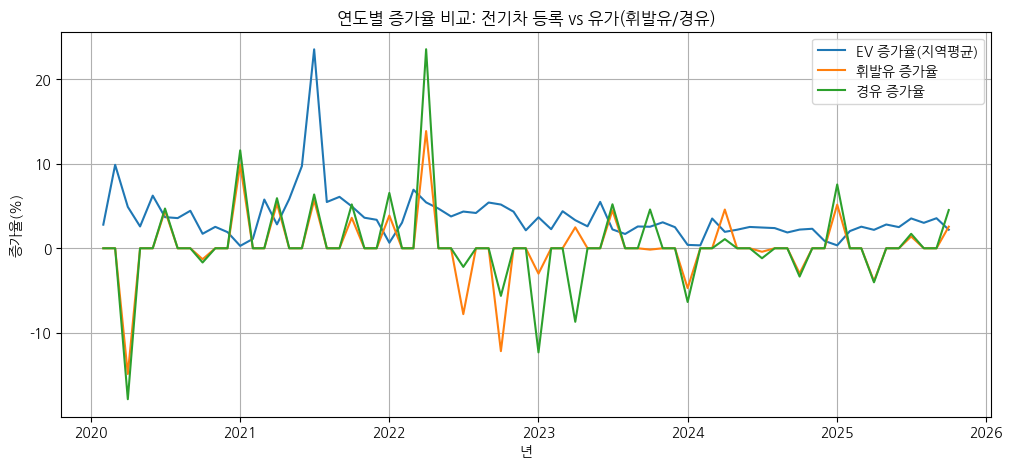

In [ ]:


import matplotlib.pyplot as plt

avg = merged.groupby("년월_dt", as_index=False)[["EV증가율(%)", "휘발유증가율(%)", "경유증가율(%)"]].mean()

plt.figure(figsize=(12,5))
plt.plot(avg["년월_dt"], avg["EV증가율(%)"], label="EV 증가율(지역평균)")
plt.plot(avg["년월_dt"], avg["휘발유증가율(%)"], label="휘발유 증가율")
plt.plot(avg["년월_dt"], avg["경유증가율(%)"], label="경유 증가율")

plt.title("연도별 증가율 비교: 전기차 등록 vs 유가(휘발유/경유)")
plt.xlabel("년")
plt.ylabel("증가율(%)")
plt.grid(True)
plt.legend()
plt.show()


연도 단위 정리

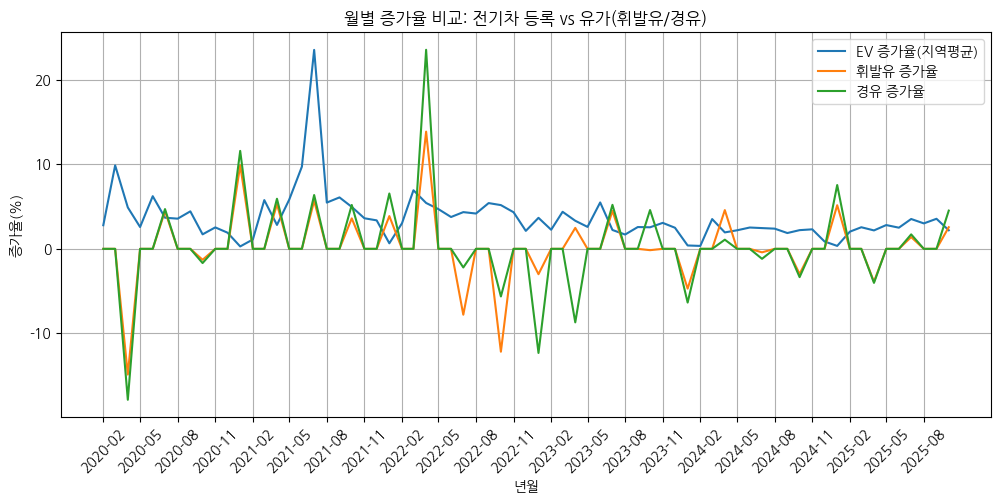

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(avg["년월_dt"], avg["EV증가율(%)"], label="EV 증가율(지역평균)")
plt.plot(avg["년월_dt"], avg["휘발유증가율(%)"], label="휘발유 증가율")
plt.plot(avg["년월_dt"], avg["경유증가율(%)"], label="경유 증가율")

plt.title("월별 증가율 비교: 전기차 등록 vs 유가(휘발유/경유)")
plt.xlabel("년월")
plt.ylabel("증가율(%)")
plt.grid(True)
plt.legend()

# x축 눈금 간격 줄이기(n개월마다 표시)
ticks = avg["년월_dt"].iloc[::3]
plt.xticks(ticks, [d.strftime("%Y-%m") for d in ticks], rotation=45)

plt.show()


지역 별로 휘발유 / 경유 중 뭐가 더 관련이 큰 지 지표로 만들기

In [ ]:
corr_table = merged.groupby("지역").apply(
    lambda x: pd.Series({
        "EV~휘발유 상관": x["EV증가율(%)"].corr(x["휘발유증가율(%)"]),
        "EV~경유 상관": x["EV증가율(%)"].corr(x["경유증가율(%)"])
    })
).reset_index()

# 어떤 쪽이 더 큰지 표시
corr_table["더큰쪽"] = corr_table.apply(
    lambda r: "휘발유" if abs(r["EV~휘발유 상관"]) >= abs(r["EV~경유 상관"]) else "경유",
    axis=1
)

corr_table = corr_table.sort_values("EV~휘발유 상관", ascending=False)

print(corr_table)


    지역  EV~휘발유 상관  EV~경유 상관  더큰쪽
9   세종   0.198498  0.228873   경유
6   대전   0.162703  0.270598   경유
14  제주   0.157750  0.218389   경유
5   대구   0.106269  0.157192   경유
3   경북   0.070922  0.060190  휘발유
12  전남   0.070087  0.172103   경유
2   경남   0.069096  0.181431   경유
8   서울   0.068547  0.080688   경유
4   광주   0.042063  0.116609   경유
1   경기   0.041549  0.117918   경유
11  인천   0.029261  0.072784   경유
15  충남   0.011667  0.115788   경유
7   부산  -0.006264  0.020209   경유
16  충북  -0.049544  0.056591   경유
13  전북  -0.066551 -0.189026   경유
10  울산  -0.072574 -0.057577  휘발유
0   강원  -0.077303 -0.256057   경유


/tmp/ipython-input-3976113896.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_table = merged.groupby("지역").apply(


특정 지역 경기(지역차 많은 곳) 1개만 골라서 그래프 보기

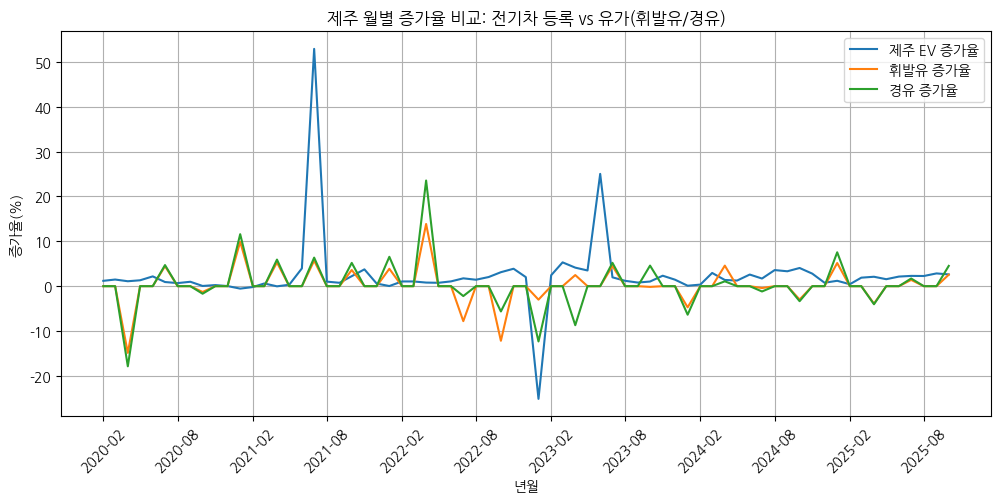

In [ ]:
target = "제주"

d = merged[merged["지역"] == target].groupby("년월_dt", as_index=False)[["EV증가율(%)", "휘발유증가율(%)", "경유증가율(%)"]].mean()

plt.figure(figsize=(12,5))
plt.plot(d["년월_dt"], d["EV증가율(%)"], label=f"{target} EV 증가율")
plt.plot(d["년월_dt"], d["휘발유증가율(%)"], label="휘발유 증가율")
plt.plot(d["년월_dt"], d["경유증가율(%)"], label="경유 증가율")

plt.title(f"{target} 월별 증가율 비교: 전기차 등록 vs 유가(휘발유/경유)")
plt.xlabel("년월")
plt.ylabel("증가율(%)")
plt.grid(True)
plt.legend()

ticks = d["년월_dt"].iloc[::6]
plt.xticks(ticks, [x.strftime("%Y-%m") for x in ticks], rotation=45)

plt.show()


In [ ]:
print(corr_table.head(5))


    지역  EV~휘발유 상관  EV~경유 상관  더큰쪽
9   세종   0.198498  0.228873   경유
6   대전   0.162703  0.270598   경유
14  제주   0.157750  0.218389   경유
5   대구   0.106269  0.157192   경유
3   경북   0.070922  0.060190  휘발유
